![](Coexistence-logo.png)

> ERC Starting Grant on COeXISTENCE between humans and machines in urban mobility.



# Milestone 1

<img src="img_mileston1.png" alt="Milestone 1 Image" width="500" height="400">

# Title: Convergence analysis using different number of paths - Experiments on one agent using PettingZoo
## Name: Anastasia
### Date: March 6, 2024
---

### Description

> This notebook explores a scenario where there is one agent in the system and randomly selects both an origin and destination, aiming to learn the optimal route among the available choices. The analysis focuses on evaluating how fast the agent converges, considering different numbers of routes. 


---

### Duration of Experiment Execution

| Number of Paths     | Time (Seconds) |
|---------------|------------------------|
| 3             | 584                    |
| 5             | 551                    |
| 10            | 1433                   |
| 20            | 2678                   |



## Experiment Summary

### Network Architecture
- Csomor network


### Agents
| **Type**          | Altruistic          |
|-------------------|---------------------|
| **Number**        | 1                 |


### Origin and Destination Details
| **Origin Count**      | 2                            |
|-----------------------|------------------------------|
| **Destination Count** | 2                            |
| **Origin Pairing**    | 279952229#0, 115604053       |
| **Destination Pairing**| -115602933#2, -441496282#1     |
    

### Hardware Utilized for Experiment Execution
| **Type of Machine** | Personal computer (or server) |
|----------------------|-------------------------------|
| **CPU**              | 12th Gen Intel(R) Core(TM) i7-1255U |
|                      | Cores: 10                   |
|                      | Sockets: 1                  |
|                      | Base Speed: 1.70 GHz        |
| **Memory**           | 16GB                          |
| **Disc (SSD)**       | 477 GB                        |
| **Operating System** | Windows 11                    |


> If we get an error in the creation of the environment we need to delete the right part of the and in utilities/path_generator.py line 27. I did this in the case of the 10 and the case of the 20 paths.

### Imported libraries 

In [1]:
import sys
sys.path.append('..')

from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

kc.PARAMS_PATH = '../params.json'

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


### 3 paths to choose from

> Change the paths of the experiments file.

In [7]:
#Define the number of paths used in this experiment
simulator_params = params[kc.SIMULATION_PARAMETERS]

for key, value in simulator_params.items():
    if key == "sumo_config_path":
        simulator_params[key] = "../Network_and_config/csomor1.sumocfg"
    if key =='edge_file_path':
        simulator_params[key] = "../Network_and_config/csomor1.edg.xml"
    if key == 'connection_file_path':
        simulator_params[key] = "../Network_and_config/csomor1.con.xml"
    if key == 'route_file_path':
        simulator_params[key] = "../Network_and_config/csomor1.rou.xml"
    if key == 'routes_xml_save_path':
        simulator_params[key] = "../Network_and_config/route.rou.xml"
    
params[kc.SIMULATION_PARAMETERS] = simulator_params

In [8]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

> Add the correct parameters in the params dict.

In [5]:
number_of_paths = 3
origins = ["279952229#0", "115604053"]
destinations = ["-335062734#1", "23130852#3"]
num_agents = 1

In [6]:
#Define the number of paths used in this experiment
simulator_params = params[kc.SIMULATION_PARAMETERS]

for key, value in simulator_params.items():
    if key == "number_of_paths":
        simulator_params[key] = number_of_paths
    if key =='origins':
        simulator_params[key] = origins
    if key == 'destinations':
        simulator_params[key] = destinations

params[kc.SIMULATION_PARAMETERS] = simulator_params

In [7]:
agent_generation_params = params[kc.AGENTS_GENERATION_PARAMETERS]

for key, value in agent_generation_params.items():
    if key == "num_agents":
        agent_generation_params[key] = num_agents

params[kc.AGENTS_GENERATION_PARAMETERS] = agent_generation_params

In [10]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [5.7363964937910366, 5.470911258671935, 3.77114253908907], (0, 1): [5.188242683682543, 6.035038003682393, 7.575525300112845], (1, 0): [3.531002871016127, 3.750388046415893, 1.9245865648108218], (1, 1): [5.109889312096328, 11.442918882921251, 5.396605683310039]}

[SUCCESS] Free flow times calculated!

Agent 0 has origin 0 and destination 0.




In [11]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [12]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [13]:
model.learn(total_timesteps=1000)

---------------------------
| time/              |    |
|    fps             | 2  |
|    iterations      | 1  |
|    time_elapsed    | 4  |
|    total_timesteps | 10 |
---------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1           |
|    iterations           | 2           |
|    time_elapsed         | 11          |
|    total_timesteps      | 20          |
| train/                  |             |
|    approx_kl            | 0.003944367 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | 0.00252     |
|    learning_rate        | 0.001       |
|    loss                 | 0.643       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0362     |
|    value_loss           | 2.06        |
-----------------------------------------
-----------------------------------------
| time

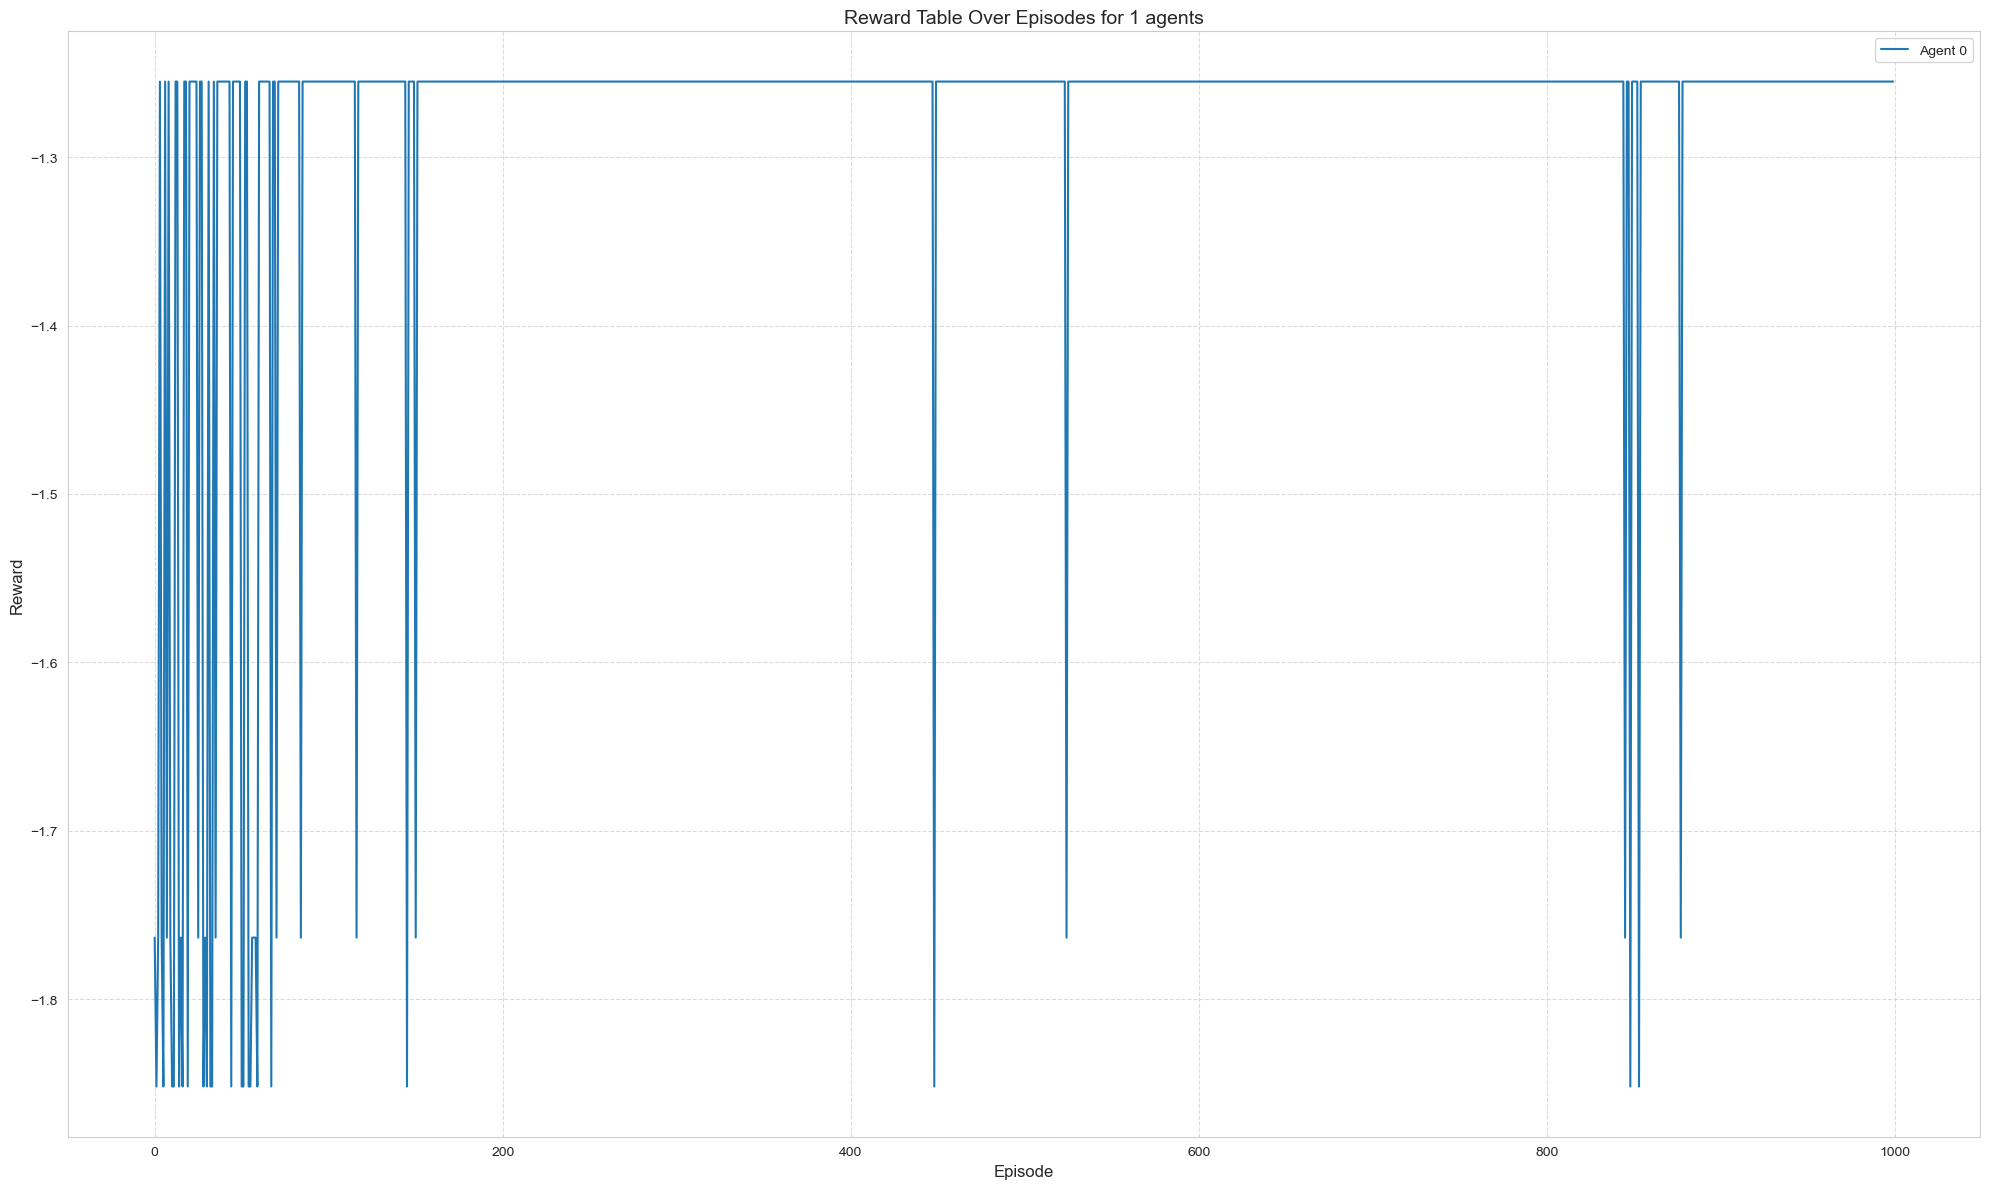

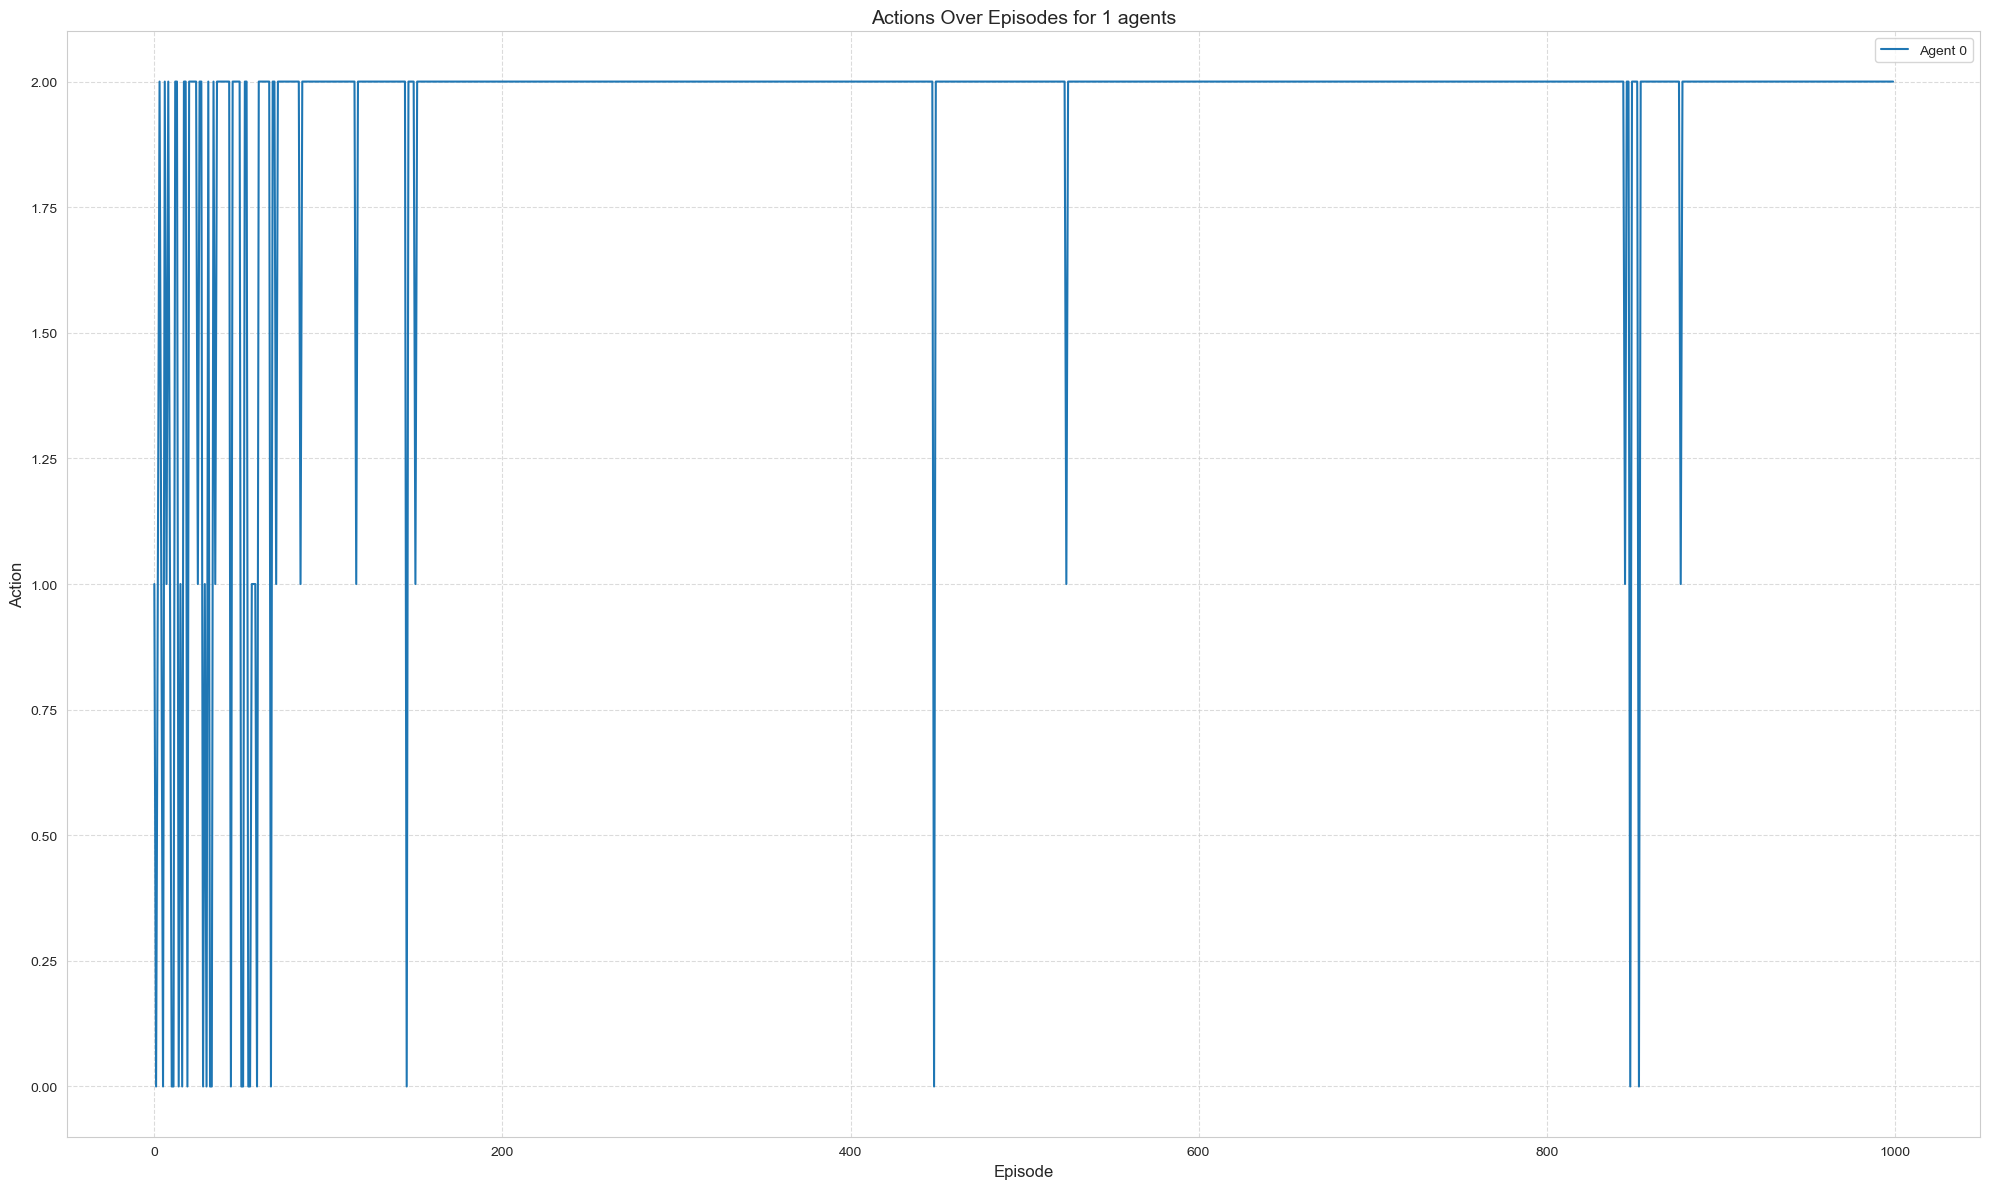

In [14]:
env.close()

### 5 paths to choose from

> Add the correct parameters in the params dict.

In [15]:
number_of_paths = 5
origins = ["279952229#0", "115604053"]
destinations = ["-335062734#1", "23130852#3"]
num_agents = 1

In [16]:
#Define the number of paths used in this experiment
simulator_params = params[kc.SIMULATION_PARAMETERS]

for key, value in simulator_params.items():
    if key == "number_of_paths":
        simulator_params[key] = number_of_paths
    if key =='origins':
        simulator_params[key] = origins
    if key == 'destinations':
        simulator_params[key] = destinations

params[kc.SIMULATION_PARAMETERS] = simulator_params

In [17]:
agent_generation_params = params[kc.AGENTS_GENERATION_PARAMETERS]

for key, value in agent_generation_params.items():
    if key == "num_agents":
        agent_generation_params[key] = num_agents

params[kc.AGENTS_GENERATION_PARAMETERS] = agent_generation_params

In [20]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 20 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [3.950609430237177, 4.72122849139656, 5.353793857777134, 2.413561266090594, 3.449139655862345], (0, 1): [11.941142199026181, 6.5613465160698325, 10.89305344888135, 8.31150814537478, 7.292768525696816], (1, 0): [2.282813347743627, 3.6322731588003525, 2.1959888654138866, 2.659899325206155, 1.9369176700300144], (1, 1): [7.825056646128574, 4.967678835393048, 7.110380385740938, 10.50984881774278, 4.589999786811772]}

[SUCCESS] Free flow times calculated!

Agent 0 has origin 1 and destination 0.




In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 20 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [99.52313151579803, 738.1681223654563, 67.75759435664993, 254.7980625101379, 50.63343101289922], (0, 1): [124.64048548144984, 99.54601023600766, 331.4658934828206, 112.7828748634084, 94.8224258877251], (1, 0): [10.450086485278058, 425.2665515862779, 27.43116081951539, 241.95718860697806, 198.57759902788493], (1, 1): [85.87998865222586, 2062.390986387125, 122.15831014784956, 2001.8203472258192, 216.08241938214135]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 1 and destination 1.


In [21]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [22]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [23]:
model.learn(total_timesteps=1000)

---------------------------
| time/              |    |
|    fps             | 2  |
|    iterations      | 1  |
|    time_elapsed    | 4  |
|    total_timesteps | 10 |
---------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2           |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 20          |
| train/                  |             |
|    approx_kl            | 0.004177141 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.61       |
|    explained_variance   | 0.0131      |
|    learning_rate        | 0.001       |
|    loss                 | 1.1         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0308     |
|    value_loss           | 3.01        |
-----------------------------------------
-----------------------------------------
| time

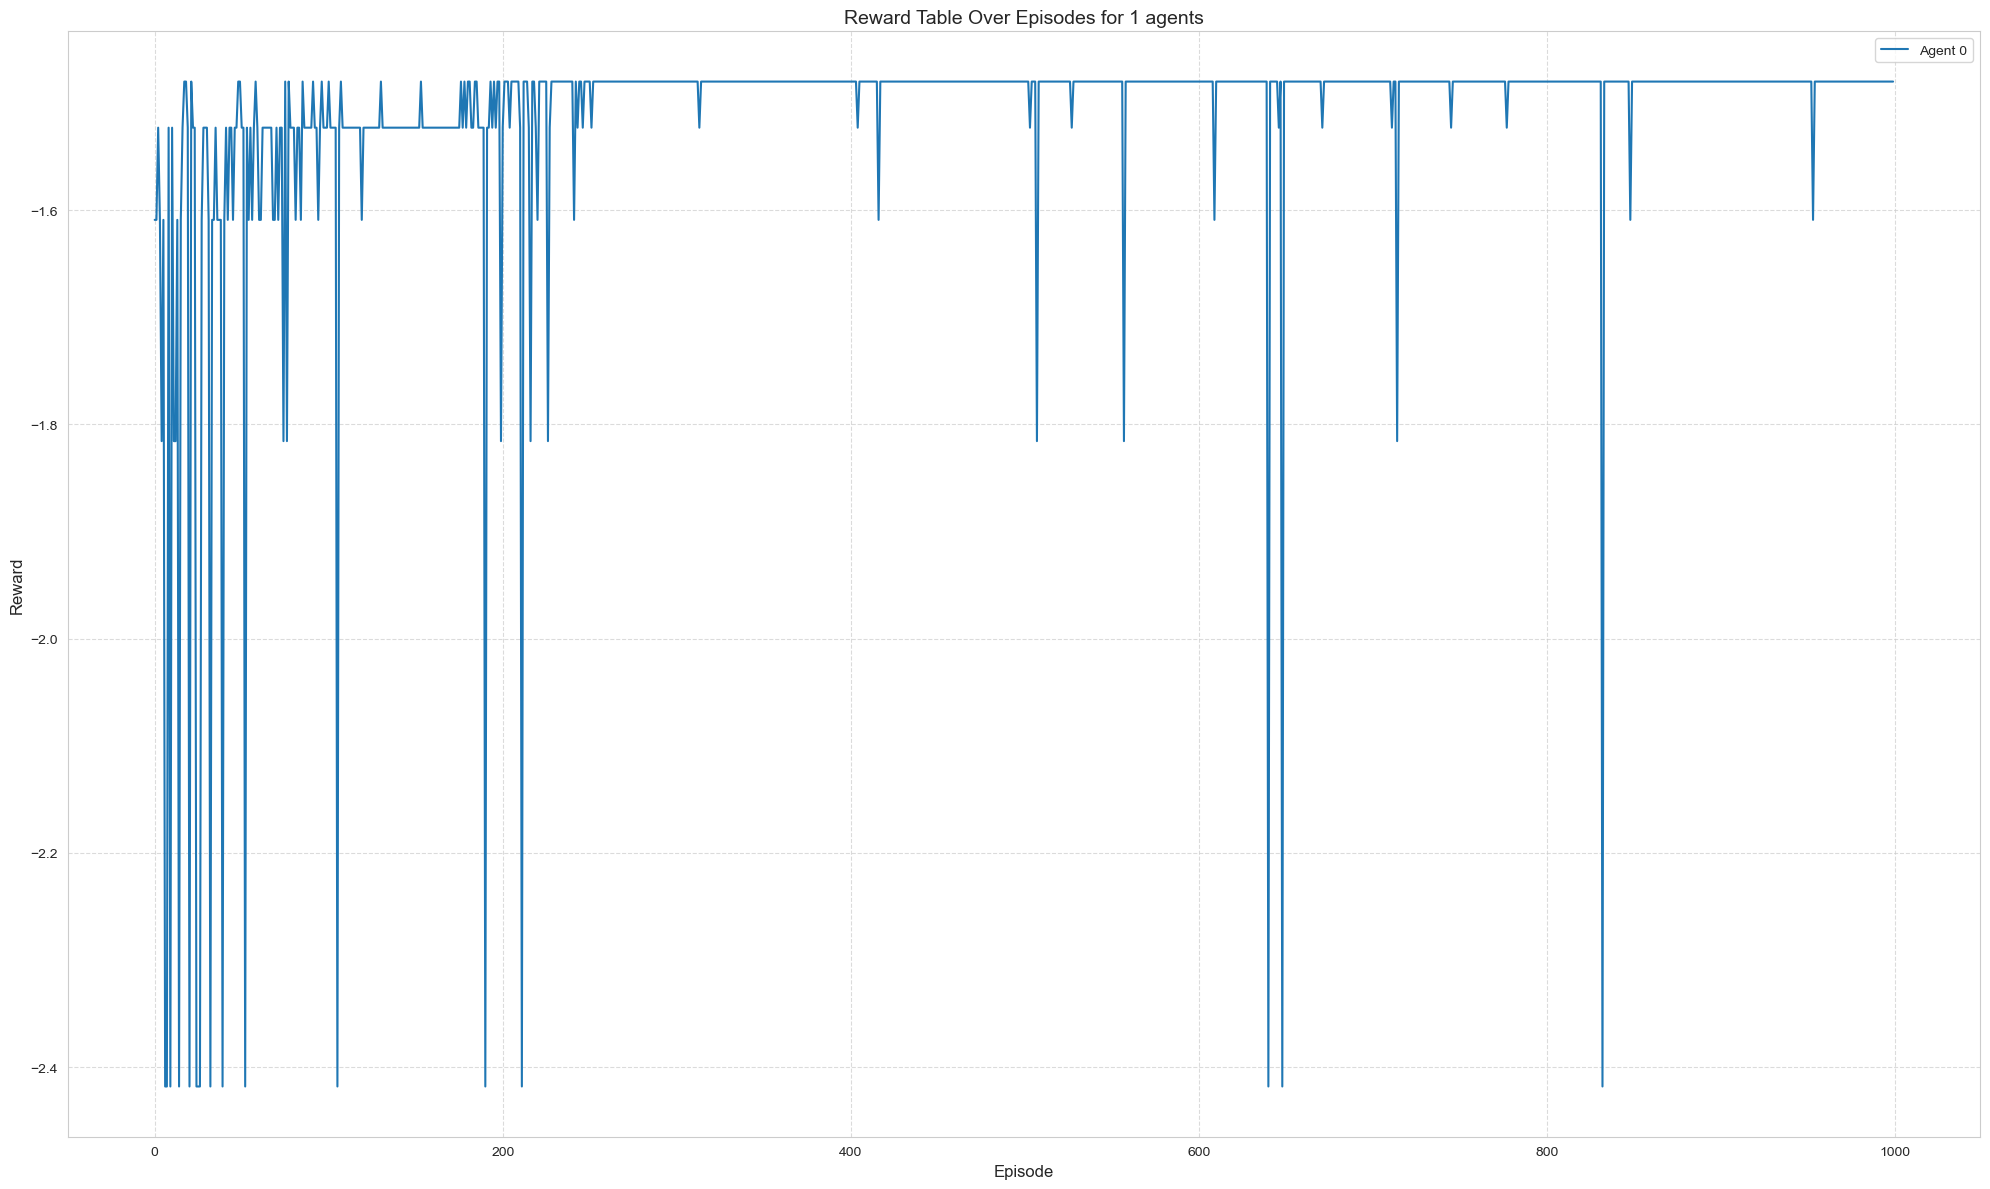

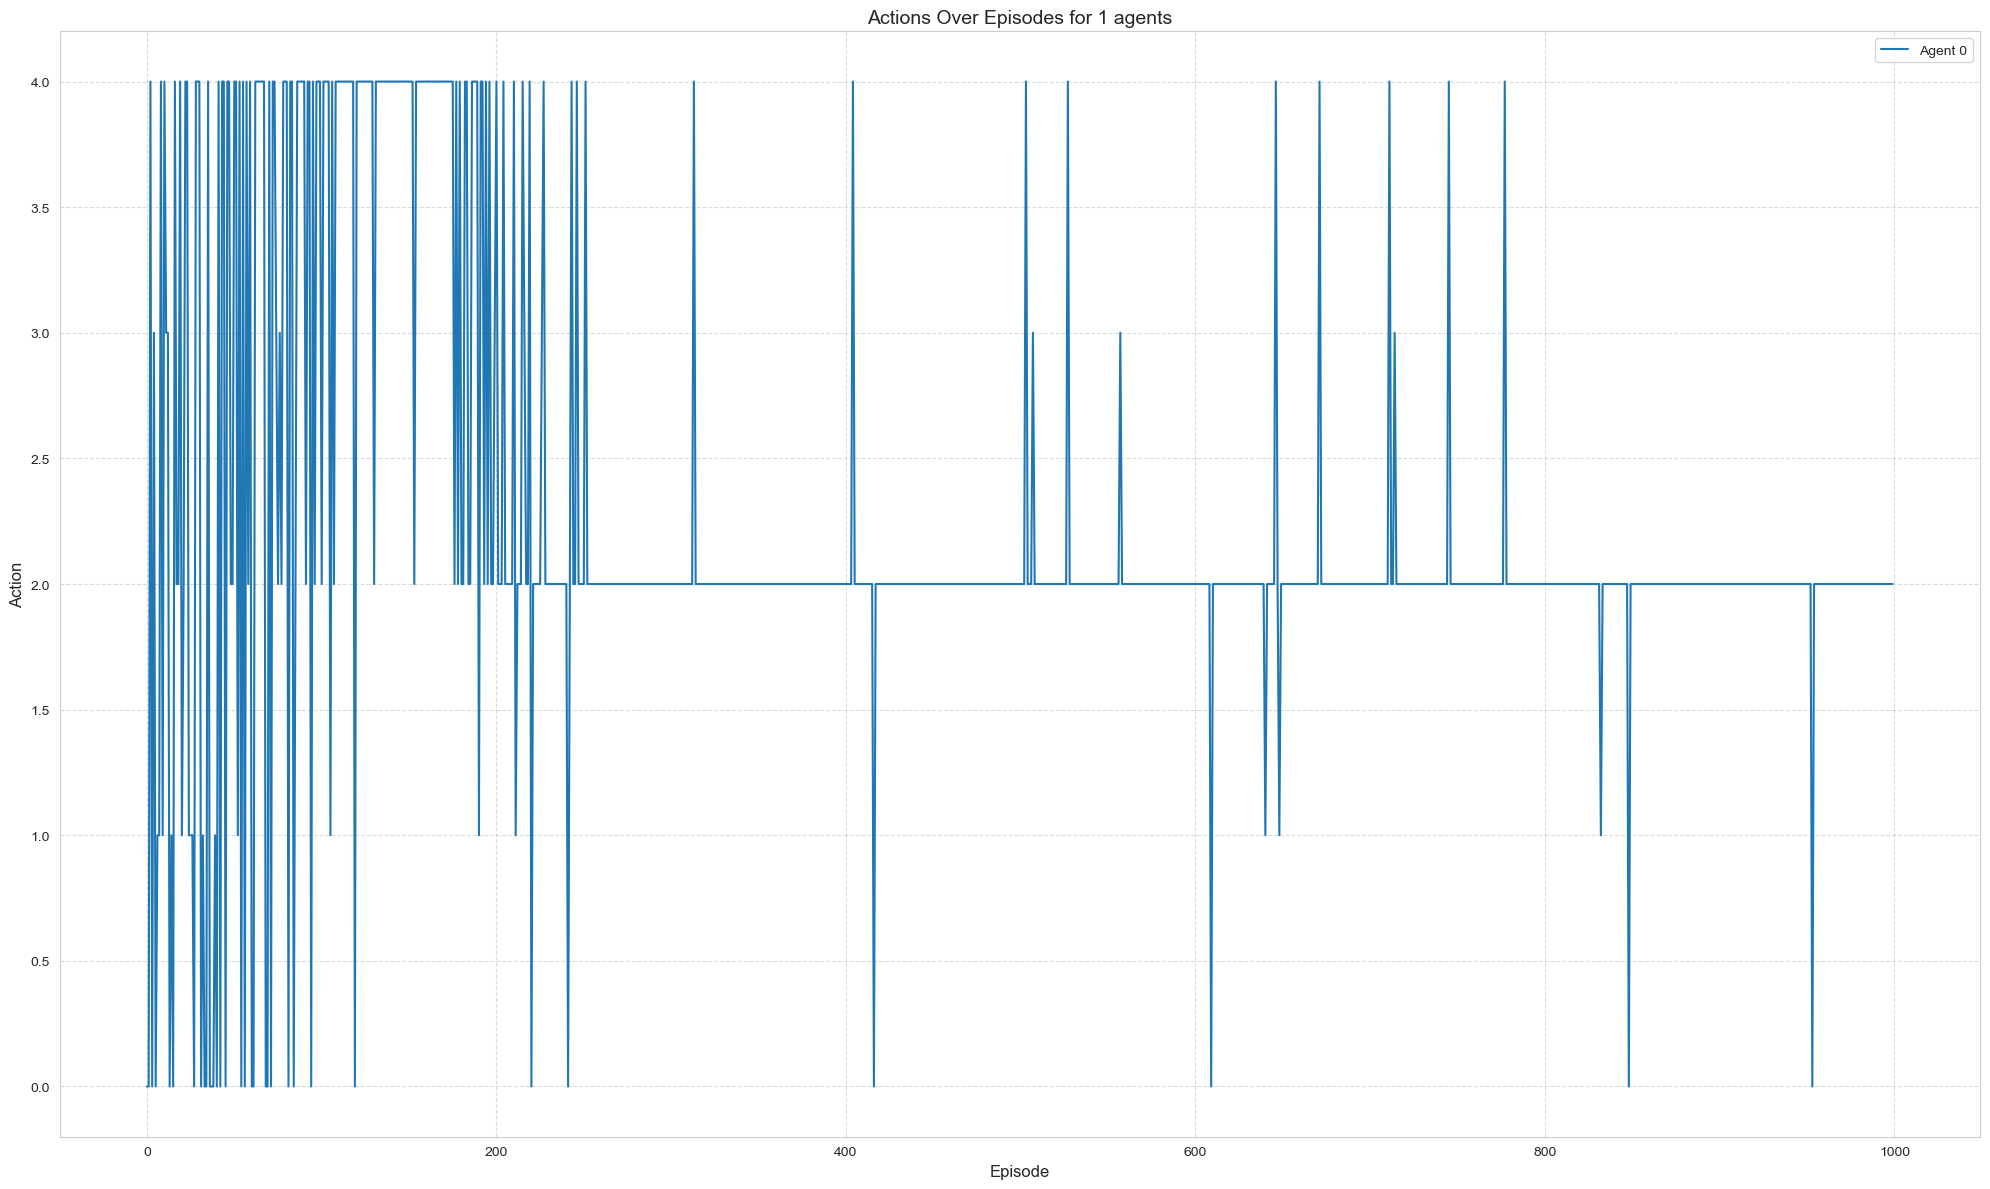

In [24]:
env.close()

### 10 paths to choose from

> Add the correct parameters in the params dict.

In [5]:
number_of_paths = 10
origins = ["279952229#0", "115604053"]
destinations = ["-335062734#1", "23130852#3"]
num_agents = 1

In [6]:
#Define the number of paths used in this experiment
simulator_params = params[kc.SIMULATION_PARAMETERS]

for key, value in simulator_params.items():
    if key == "number_of_paths":
        simulator_params[key] = number_of_paths
    if key =='origins':
        simulator_params[key] = origins
    if key == 'destinations':
        simulator_params[key] = destinations

params[kc.SIMULATION_PARAMETERS] = simulator_params

In [7]:
agent_generation_params = params[kc.AGENTS_GENERATION_PARAMETERS]

for key, value in agent_generation_params.items():
    if key == "num_agents":
        agent_generation_params[key] = num_agents

params[kc.AGENTS_GENERATION_PARAMETERS] = agent_generation_params

In [8]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 40 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [98.07564933562261, 218.07383459859645, 416.5958618681518, 20.2342677243165, 95.25352955942692, 782.1963865778893, 539.0192640156208, 14.314308444111926, 155.32978152152674, 81.33195594419492], (0, 1): [104.3570720266807, 229.65854274261872, 35.28092066200131, 112.06546435789964, 637.6098120236037, 494.60138501942004, 169.3415165839332, 187.3468137632616, 115.0389294981615, 181.6647602921368], (1, 0): [291.2246569534141, 71.28269803944397, 70.98097039453936, 8.341370950682276, 25.164240969625762, 622.9449546221482, 214.5423425148145, 177.27741123909973, 127.1882659441324, 16.059438024133467], (1, 1): [1716.657492883125, 56.56510311867895, 201.23247907988892, 243.57528580792075, 42.96018354147568, 209.4238882788554, 278.52301092837695, 26.779138883775254, 718.8214925400799, 41.39759526560807]}

[SUCCE

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 40 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [15.071187884801143, 38.649135290617274, 59.106279500918326, 149.71162317347662, 22.25251796488173, 59.457626685348814, 3.8194658421424372, 92.14754623234164, 397.41119233514195, 420.9898433153746], (0, 1): [243.14082387074038, 2033.4597050011853, 1048.7064301623195, 524.6716870728849, 26.767266042486135, 310.6266913437183, 1719.0040645918325, 22.411617680991327, 1737.0879711699663, 62.79919597788722], (1, 0): [183.7011421883962, 7.587720338109484, 9.91707281764168, 19.979997484008635, 275.8039351263601, 13.496502192618502, 3.0592462018455455, 1160.6709351722723, 1116.1906236678649, 58.67905485148825], (1, 1): [169.53742282947755, 586.9881127900381, 314.2003112970922, 3267.1520117920863, 166.14711710806245, 87.2941608055844, 513.2517346646824, 1780.7557541582723, 132.5984517381403, 37.727872675348046]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 0 and desti

In [9]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [10]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    device = "cuda",
    **tuned_params
)

Using cpu device


In [11]:
model.learn(total_timesteps=1000)

---------------------------
| time/              |    |
|    fps             | 0  |
|    iterations      | 1  |
|    time_elapsed    | 62 |
|    total_timesteps | 10 |
---------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 0            |
|    iterations           | 2            |
|    time_elapsed         | 152          |
|    total_timesteps      | 20           |
| train/                  |              |
|    approx_kl            | 0.0044584395 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.3         |
|    explained_variance   | 0.00662      |
|    learning_rate        | 0.001        |
|    loss                 | 352          |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0306      |
|    value_loss           | 712          |
------------------------------------------
------------------------------

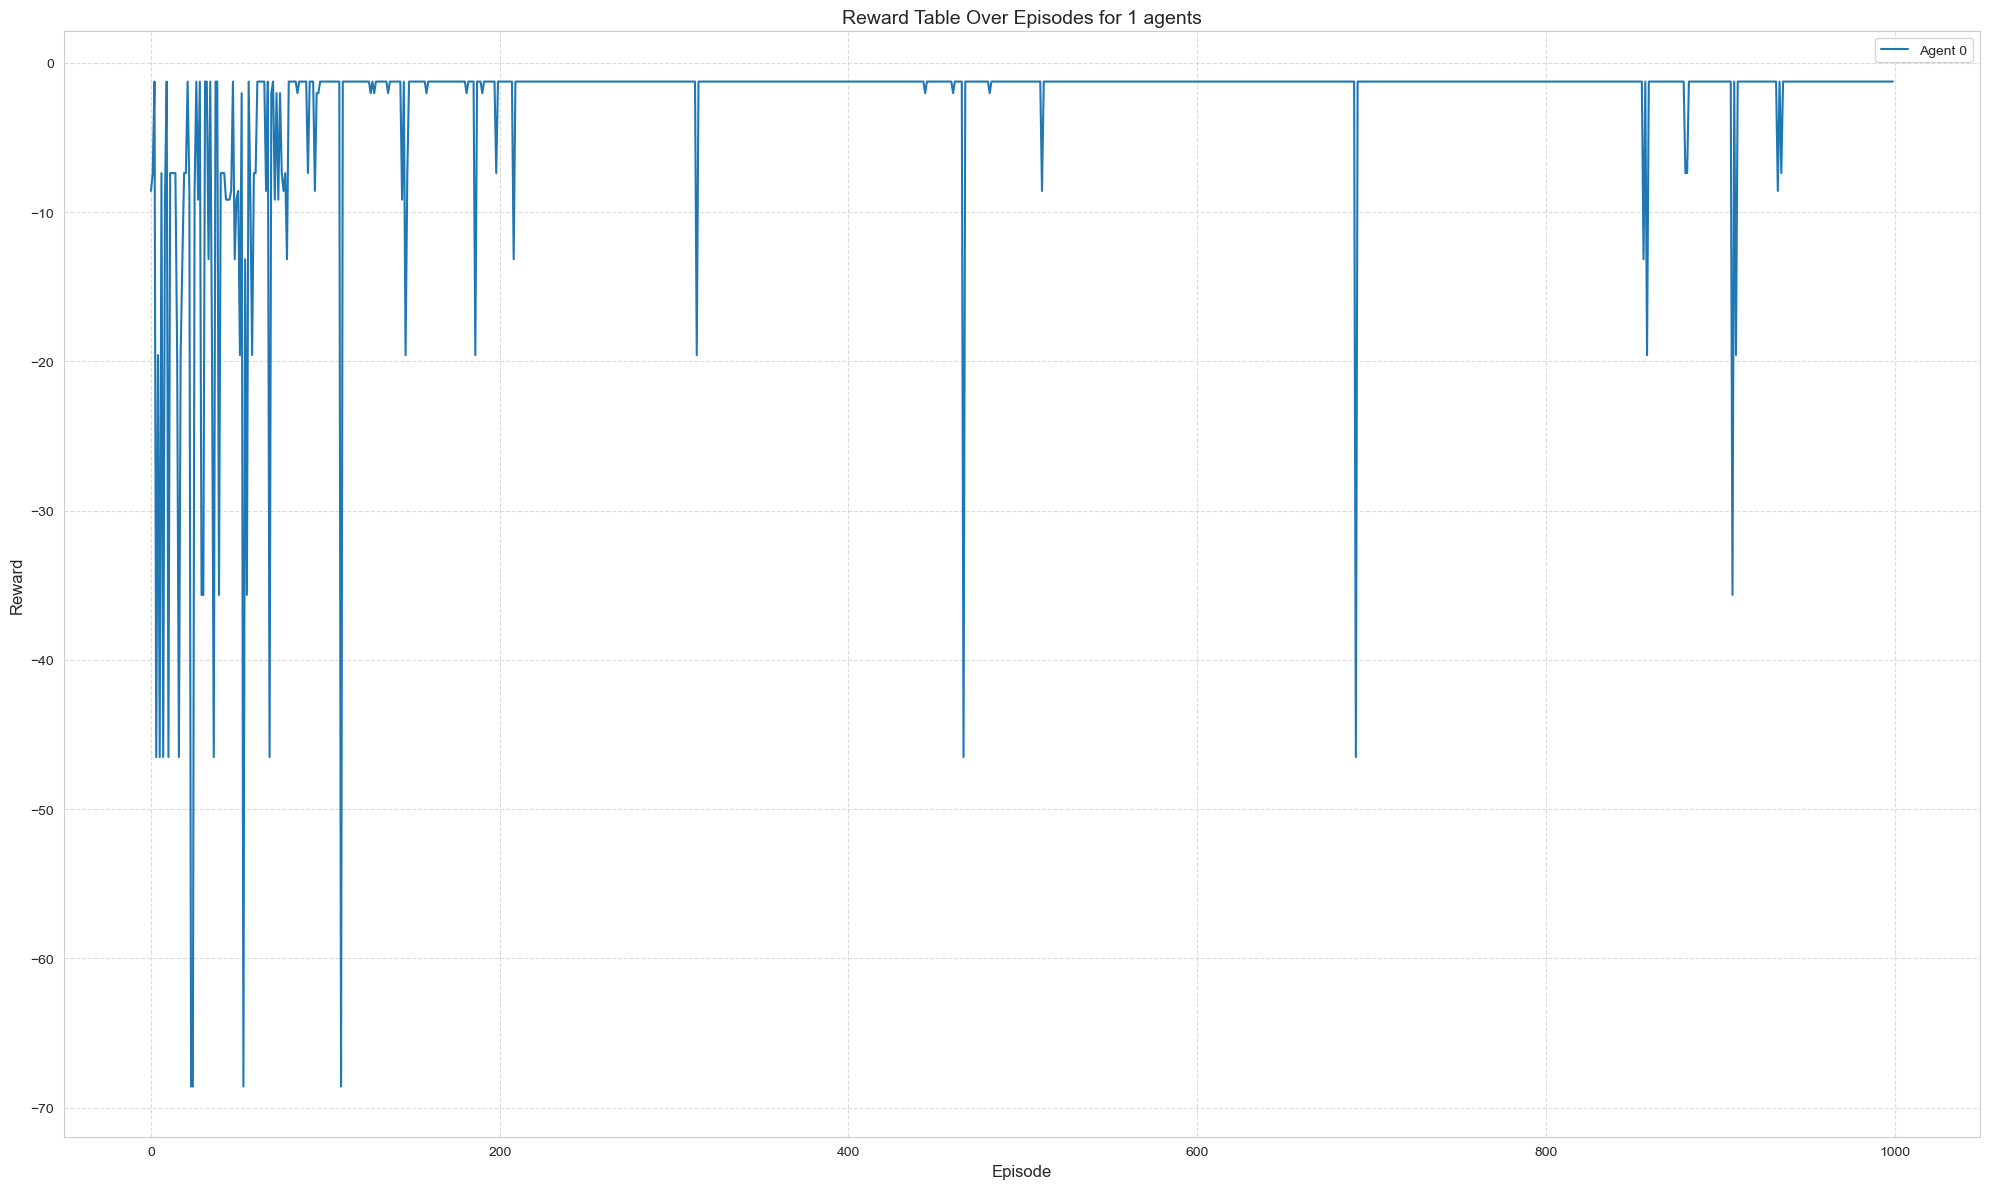

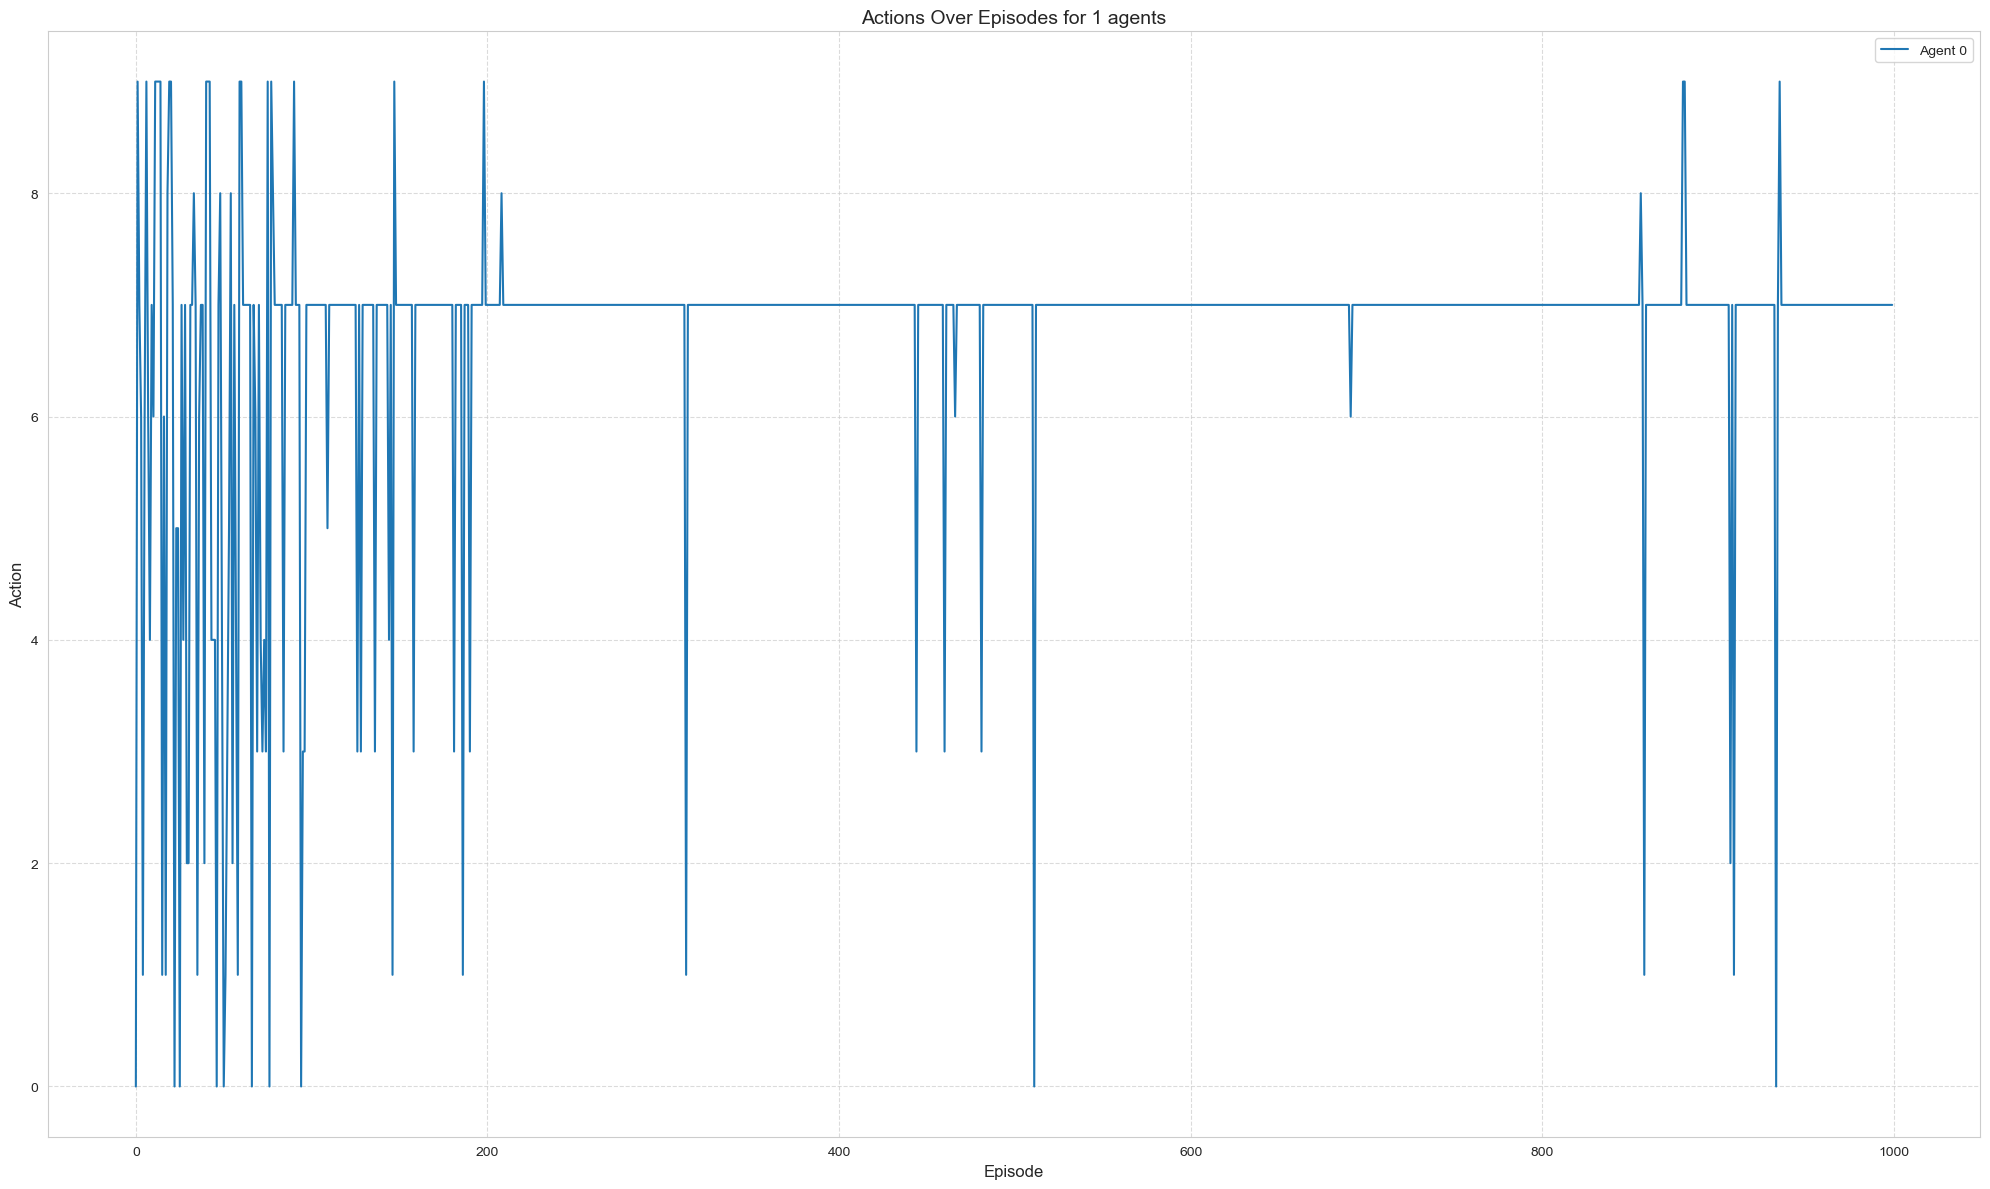

In [12]:
env.close()

## 20 paths to choose

> Add the correct parameters in the params dict.

In [9]:
number_of_paths = 20
origins = ["279952229#0", "115604053"]
destinations = ["-335062734#1", "23130852#3"]
num_agents = 1

In [10]:
#Define the number of paths used in this experiment
simulator_params = params[kc.SIMULATION_PARAMETERS]

for key, value in simulator_params.items():
    if key == "number_of_paths":
        simulator_params[key] = number_of_paths
    if key =='origins':
        simulator_params[key] = origins
    if key == 'destinations':
        simulator_params[key] = destinations

params[kc.SIMULATION_PARAMETERS] = simulator_params

In [11]:
agent_generation_params = params[kc.AGENTS_GENERATION_PARAMETERS]

for key, value in agent_generation_params.items():
    if key == "num_agents":
        agent_generation_params[key] = num_agents

params[kc.AGENTS_GENERATION_PARAMETERS] = agent_generation_params

In [12]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 80 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [19.007510882428033, 25.51268519307834, 383.9518622394006, 336.48279796371327, 2301.829010440823, 57.787294958263864, 28.615053523209152, 1070.2458452069386, 33.52437779741173, 229.14623310779504, 426.80628508597846, 11.280172415166993, 19.802701878319205, 275.79977519543394, 160.62954933092183, 37.61670825396841, 24.356897678429394, 9.284787196746842, 23.052566571098655, 131.64095636248868], (0, 1): [109.45590804535878, 234.72238248472925, 44.787963968884895, 318.0141589766781, 40.39528547831678, 34.81030608782604, 1417.561473560376, 223.00093540620935, 111.24816304736392, 240.3113260166437, 211.53641726691058, 105.77189959071217, 1870.829647296272, 6405.212930562629, 175.09689326596916, 307.03695123548164, 809.265759652569, 344.32382433153407, 721.0007058089918, 378.32713090935124], (1, 0): [63.380

In [13]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [14]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [15]:
model.learn(total_timesteps=1000)

----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 796 |
|    total_timesteps | 10  |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 0            |
|    iterations           | 2            |
|    time_elapsed         | 1159         |
|    total_timesteps      | 20           |
| train/                  |              |
|    approx_kl            | 0.0028101087 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -3           |
|    explained_variance   | 0.000531     |
|    learning_rate        | 0.001        |
|    loss                 | 6.25e+03     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0332      |
|    value_loss           | 1.25e+04     |
------------------------------------------
-----------------------

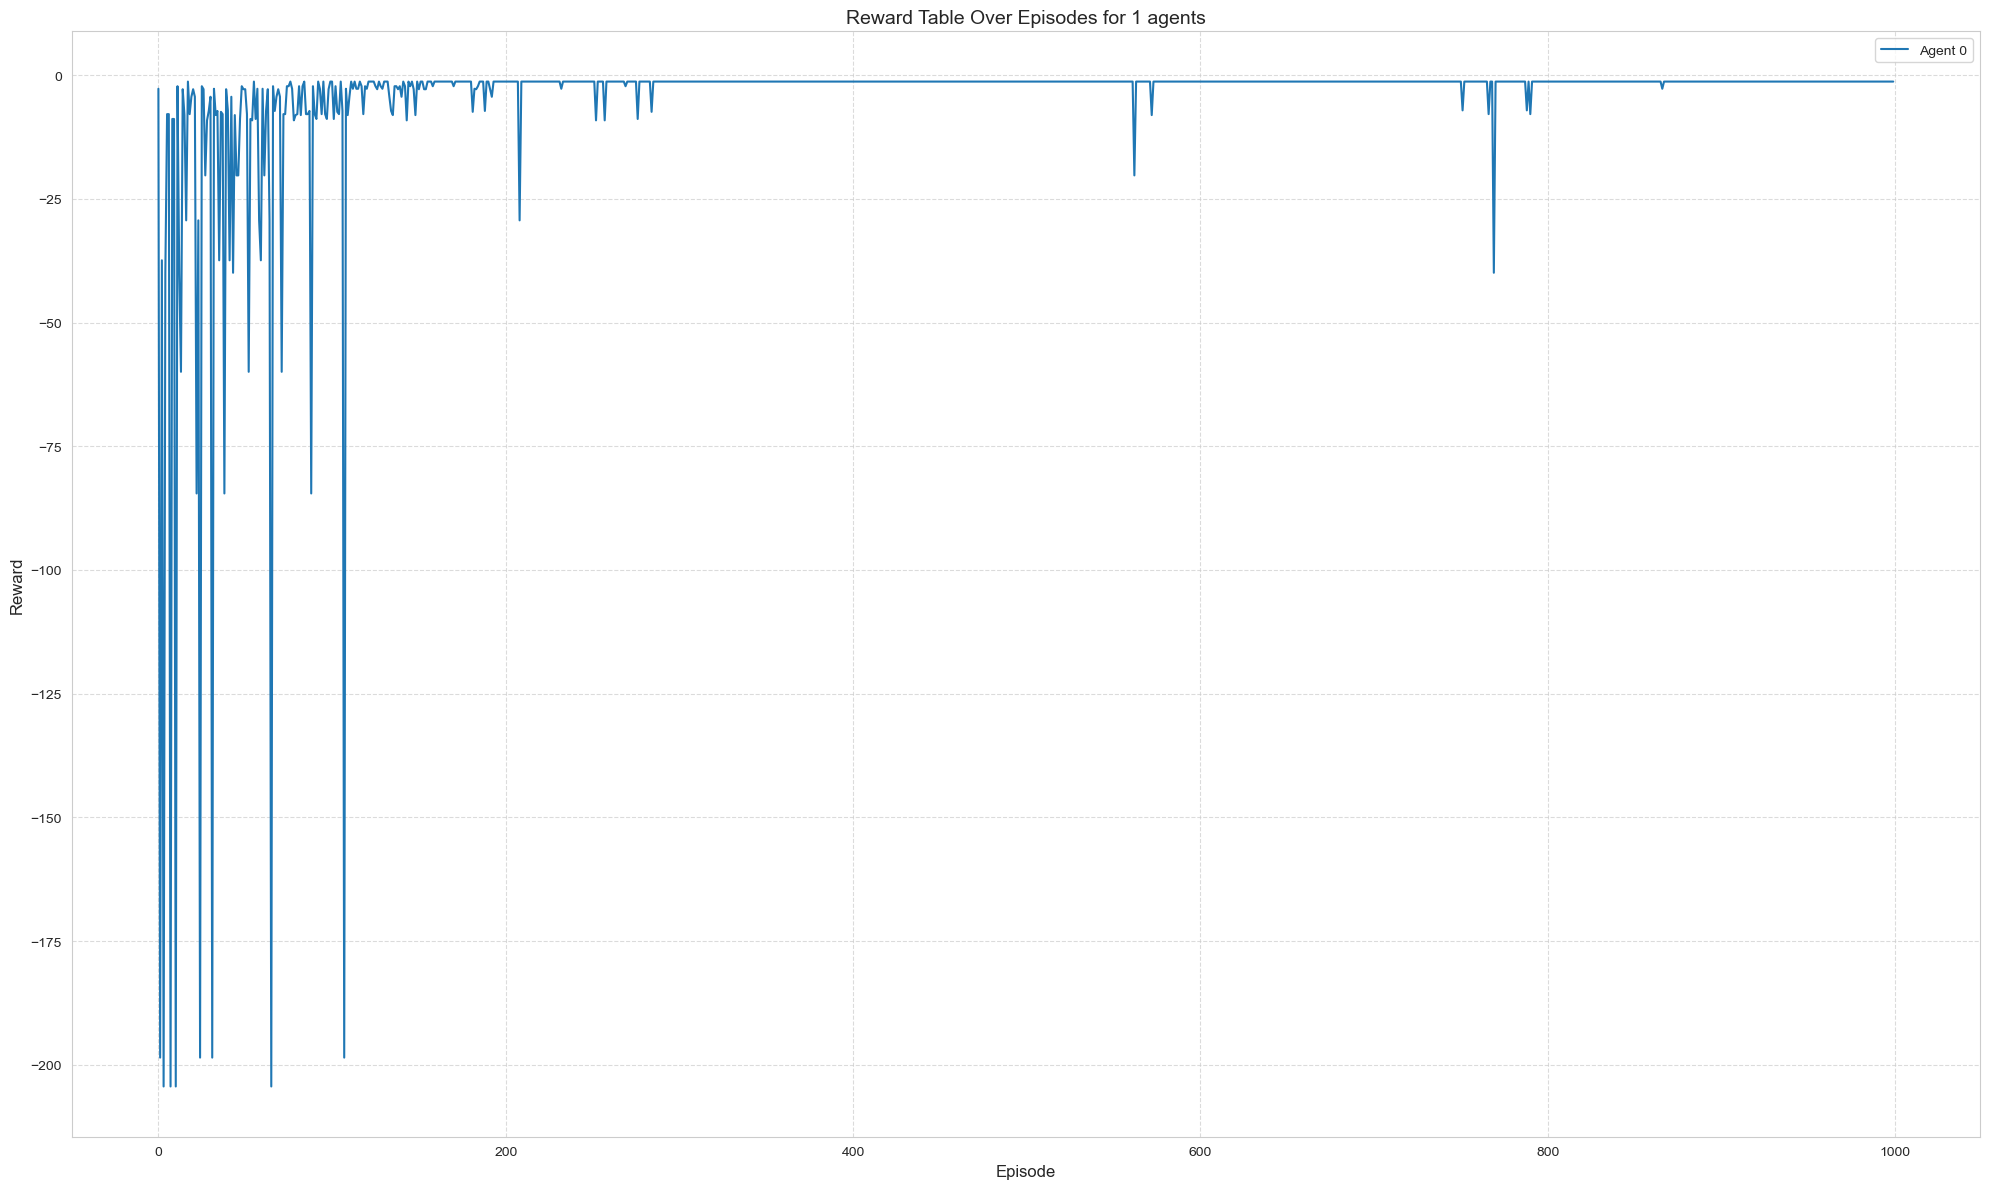

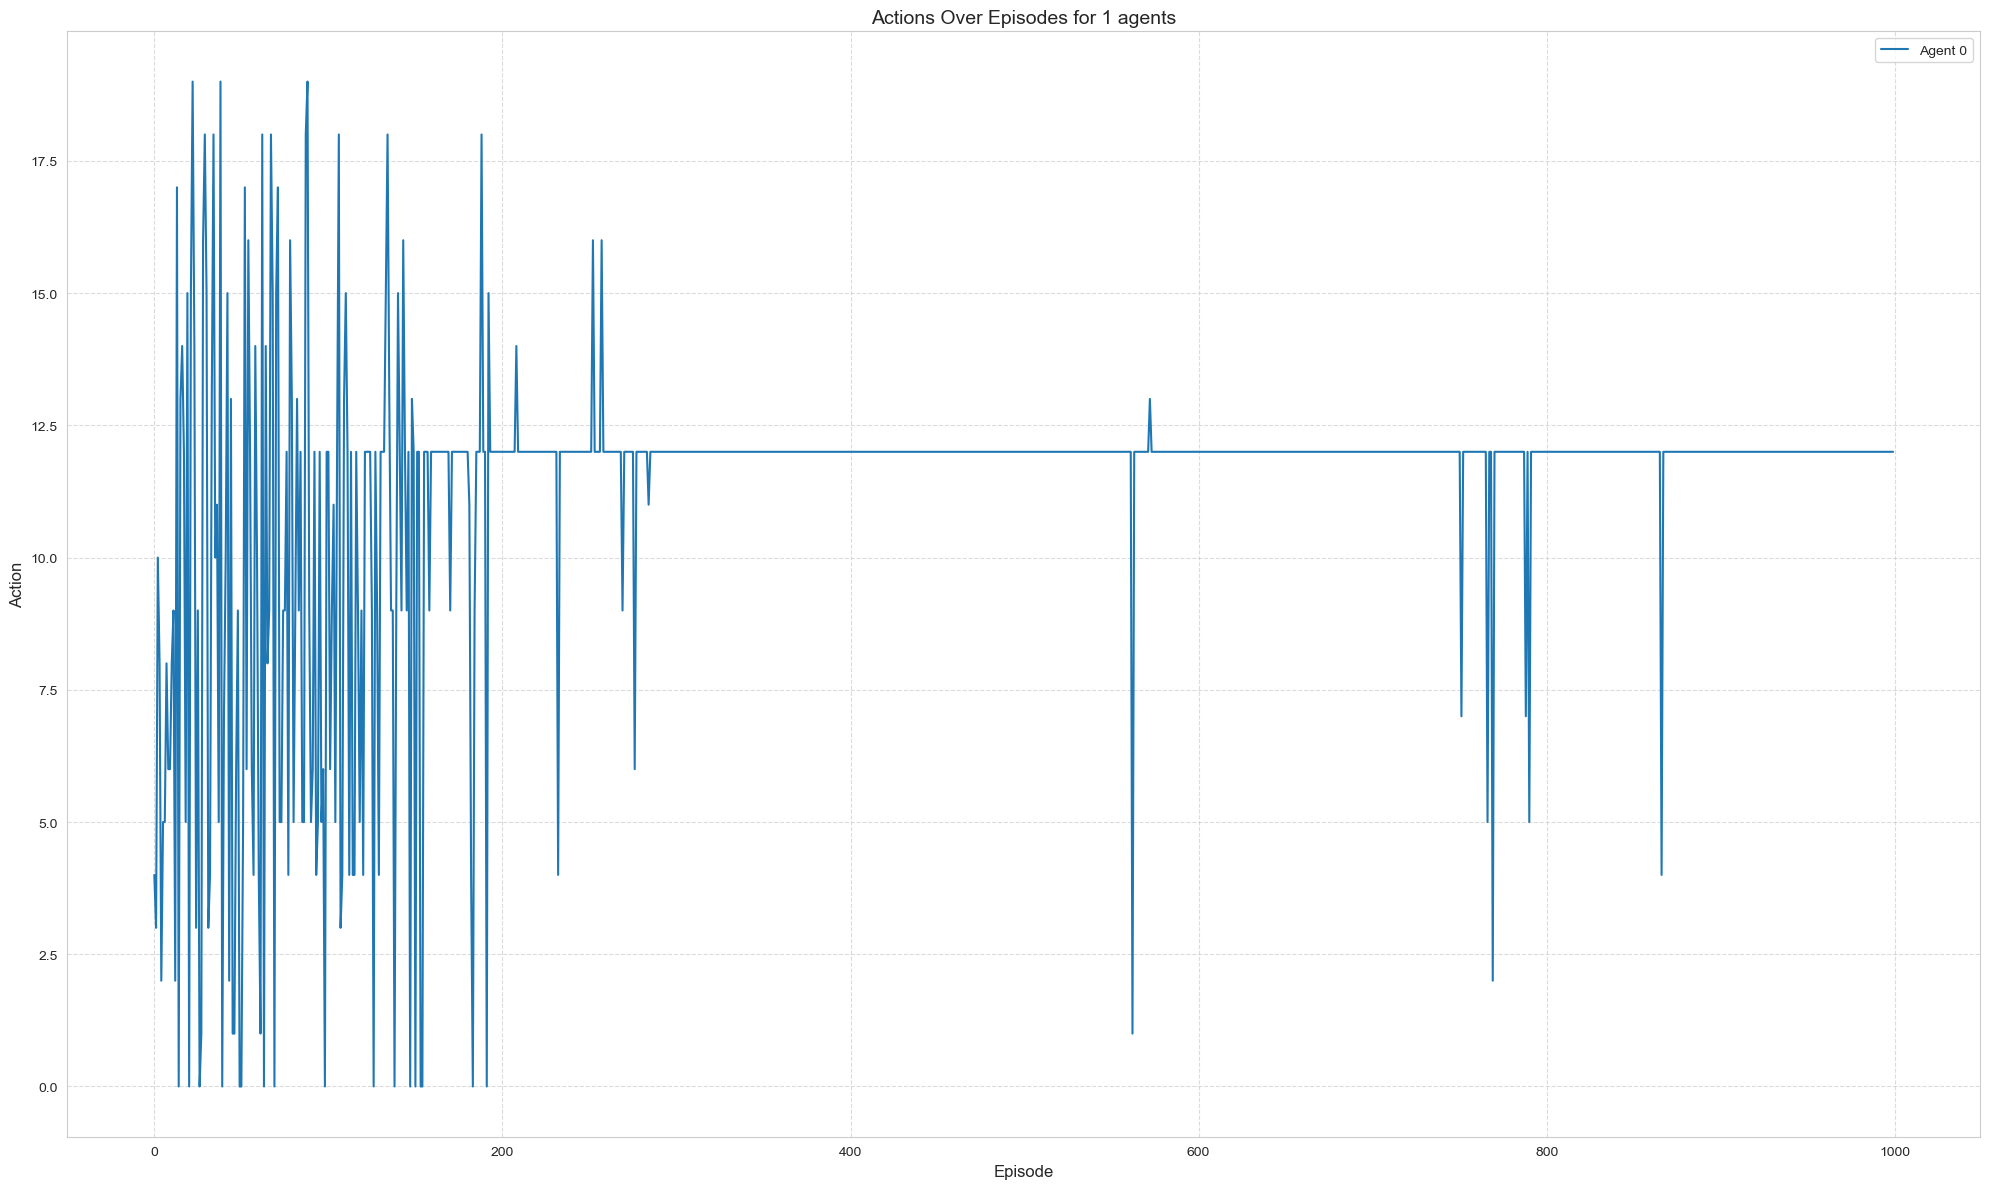

In [16]:
env.close()

# Results

> In all scenarios, the agent achieves convergence within 200 episodes.

---